In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


<Axes: xlabel='blood_glucose_level', ylabel='Count'>

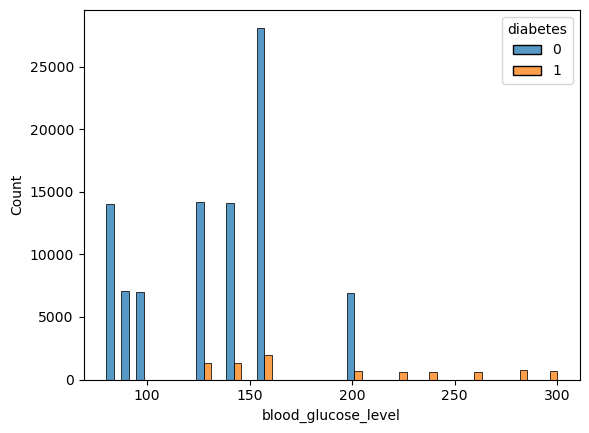

In [18]:
df = pd.read_csv("diabetes_predicton_dataset.csv")
df.head()
sns.histplot(
    data = df,
    x = "blood_glucose_level",
    hue = "diabetes",
    bins = 30,
    multiple = "dodge"
)
# dependent_criteria = age,bmi,HbA1c_level,blood_glucose_level

<Axes: >

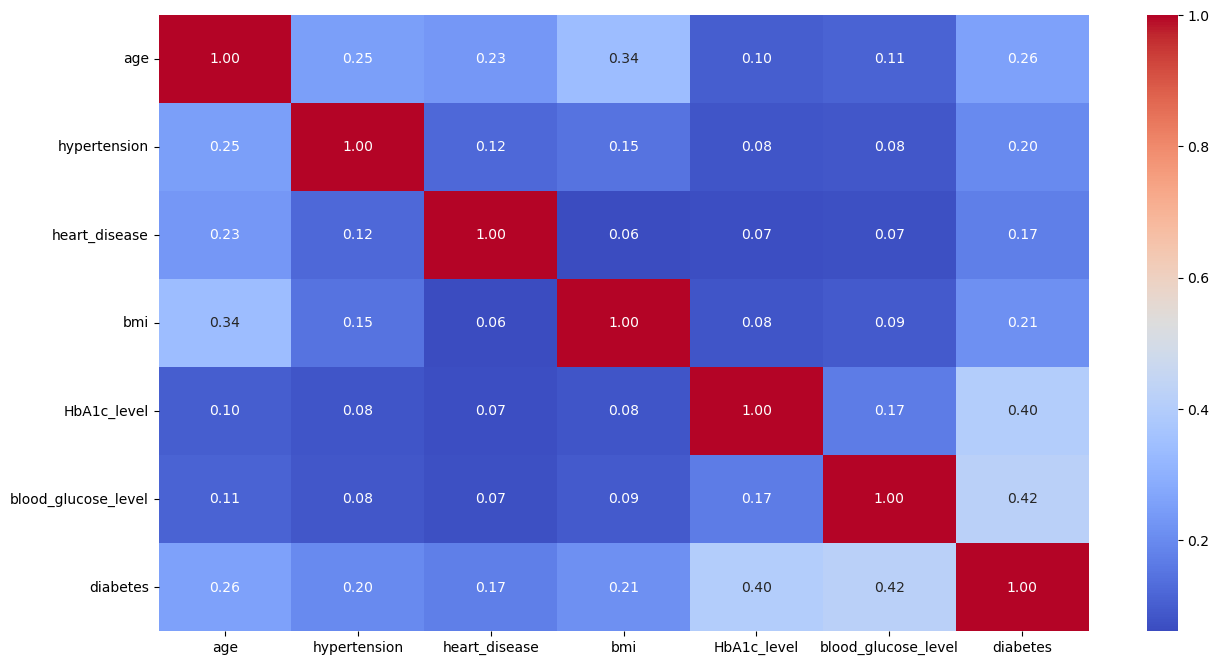

In [19]:
# correlation_heatmap...

num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [44]:
x = df.drop(columns = ["diabetes"])

In [45]:
y = df["diabetes"]

In [46]:
print(x.head())
print(y.head())
df.describe()


   gender   age  hypertension  heart_disease    bmi  HbA1c_level  \
0       0  80.0             0              1  25.19          6.6   
1       0  54.0             0              0  27.32          6.6   
2       1  28.0             0              0  27.32          5.7   
3       0  36.0             0              0  23.45          5.0   
4       1  76.0             1              1  20.14          4.8   

   blood_glucose_level  smoking_history_current  smoking_history_ever  \
0                  140                      0.0                   0.0   
1                   80                      0.0                   0.0   
2                  158                      0.0                   0.0   
3                  155                      1.0                   0.0   
4                  155                      1.0                   0.0   

   smoking_history_former  smoking_history_never  smoking_history_not current  
0                     0.0                    1.0                        

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000
mean,0.414660,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000,0.092860,0.040040,0.093520,0.35095,0.06447
std,0.493031,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883,0.290238,0.196054,0.291161,0.47727,0.24559
min,0.000000,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
25%,0.000000,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
50%,0.000000,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
75%,1.000000,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.00000
max,2.000000,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000


In [47]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

# One Hot Encoding
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)
df.describe()


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000
mean,0.414660,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000,0.092860,0.040040,0.093520,0.35095,0.06447
std,0.493031,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883,0.290238,0.196054,0.291161,0.47727,0.24559
min,0.000000,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
25%,0.000000,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
50%,0.000000,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000
75%,1.000000,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.00000
max,2.000000,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000


In [48]:
# scaling of the data...

from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test = train_test_split(
     x,y,test_size = 0.2,random_state = 42
 )
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [49]:
print(x_train.dtypes)

gender                           int64
age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
smoking_history_current        float64
smoking_history_ever           float64
smoking_history_former         float64
smoking_history_never          float64
smoking_history_not current    float64
dtype: object


In [50]:
print(x_train["gender"])

75220    1
48955    1
44966    0
13568    0
92727    0
        ..
6265     1
54886    0
76820    1
860      0
15795    0
Name: gender, Length: 80000, dtype: int64


In [76]:
# logistic regression...
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_prob = log_model.predict_proba(x_test_scaled)[:, 1]
y_pred = (y_prob > 0.3).astype(int)  # lower threshold

# evaluation....

print("recall score : ",recall_score(y_test,y_pred))
print("precision_score is : ",precision_score(y_test,y_pred))
print("f1 score is : ",f1_score(y_test,y_pred))
print("accuracy_score is : ",accuracy_score(y_test,y_pred))
print("confusion matrix is : ",confusion_matrix(y_test,y_pred))

recall score :  0.7107728337236534
precision_score is :  0.7243436754176611
f1 score is :  0.7174940898345153
accuracy_score is :  0.9522
confusion matrix is :  [[17830   462]
 [  494  1214]]


In [71]:
# knn ...

from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 7)
knn_model.fit(x_train_scaled,y_train)
y_prob = knn_model.predict_proba(x_test_scaled)[:, 1]
y_pred2 = (y_prob > 0.3).astype(int)  # lower threshold

print("recall score : ",recall_score(y_test,y_pred2))
print("precision_score is : ",precision_score(y_test,y_pred2))
print("f1 score is : ",f1_score(y_test,y_pred2))
print("accuracy_score is : ",accuracy_score(y_test,y_pred2))
print("confusion matrix is : ",confusion_matrix(y_test,y_pred2))

recall score :  0.6668618266978923
precision_score is :  0.7953910614525139
f1 score is :  0.7254777070063694
accuracy_score is :  0.9569
confusion matrix is :  [[17999   293]
 [  569  1139]]


In [77]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_prob = nb_model.predict_proba(x_test_scaled)[:, 1]
y_pred3 = (y_prob > 0.5).astype(int)  # lower threshold

print("recall score : ",recall_score(y_test,y_pred3))
print("precision_score is : ",precision_score(y_test,y_pred3))
print("f1 score is : ",f1_score(y_test,y_pred3))
print("accuracy_score is : ",accuracy_score(y_test,y_pred3))
print("confusion matrix is : ",confusion_matrix(y_test,y_pred3))

recall score :  0.6428571428571429
precision_score is :  0.4578815679733111
f1 score is :  0.5348270823185582
accuracy_score is :  0.9045
confusion matrix is :  [[16992  1300]
 [  610  1098]]
